In [14]:

import os
import mat73
import torch
import numpy as np
import matplotlib.pyplot as plt
from slope2noise.utils import octave_filtering
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
import DecayFitNet.python.toolbox as decayfitnet
import DecayFitNet.python.toolbox.DecayFitNetToolbox as dfn


Load parameters from Georg's dataset 

In [1]:
dataset_path = "/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/Common_Slope_Analysis_Results"
# pick one random file from the dataset 
filepath = "cs_analysis_results_omni_1000.mat"
# read the mat file 
data = mat73.loadmat(os.path.join(dataset_path, filepath))['analysisResults']
# load the impulse responses 
srirs = mat73.loadmat("/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/srirs.mat")['srirDataset']


NameError: name 'mat73' is not defined

In [16]:

fs = srirs['fs'].item() # sampling frequnecy
L = srirs['srirs'].shape[1] # length of the impulse responses

In [17]:
loc_indx = 800   # location index [0, 838]
ref_rir = srirs['srirs'][loc_indx, :, 0]   # assuming that the omnidirectional is the first channel

In [18]:

# Option 1 filter the impulse responses in octave bands
ref_rir_filt = octave_filtering(ref_rir, fs, [125, 250, 500, 1000, 2000, 4000, 8000], compensate_filter_energy=True)[:, 3]

# decayfitnet_octave_filtering = decayfitnet.core.FilterByOctaves()
# ref_rir_defn_filt = decayfitnet_octave_filtering(torch.tensor(ref_rir))[3, :].numpy()

In [29]:
# Option 2 
dfn_1000 = dfn.DecayFitNetToolbox(n_slopes=0, sample_rate=fs, filter_frequencies=[1000])
estimated_param, norm_vals_decayfitnet = dfn_1000.estimate_parameters(ref_rir, analyse_full_rir=False)

In [22]:
from slope2noise.utils import schroeder_backward_int
from slope2noise.dataclass import *
from slope2noise.generate import *
time_axis = np.arange(0, L) / fs

# DecayFitNet finds the optimal number of slopes and set the rest to zero
valid_slopes =  np.nonzero(data['tVals_standard'][loc_indx, :])[0]

isStandard = True
if isStandard: 
    t_vals = data['tVals_standard'][loc_indx, valid_slopes] 
    a_vals =  data['aVals_standard'][loc_indx, valid_slopes] 
    n_vals = data['nVals_standard'][loc_indx]
else: 
    t_vals = data['commonDecayTimes'] 
    a_vals =  data['aVals'][loc_indx, ...] 
    n_vals = data['nVals'][loc_indx]

# build edc model using decayfitnet
edc_decayfitnet = decayfitnet.core.decay_model(torch.from_numpy(np.expand_dims(t_vals, (0 ))),
                                                        torch.from_numpy(np.expand_dims(a_vals, (0))),
                                                        torch.from_numpy(np.expand_dims(np.array(n_vals), (0))),
                                                        time_axis=torch.from_numpy(time_axis),
                                                        compensate_uli=False,
                                                        backend='torch').squeeze()

ref_edc_decayfitnet = decayfitnet.core.decay_model(torch.from_numpy(estimated_param[0]),
                                     torch.from_numpy(estimated_param[1]),
                                     torch.from_numpy(estimated_param[2]),
                                     time_axis=torch.from_numpy(time_axis),
                                     compensate_uli=True,
                                     backend='torch')

Compare for the BROADBAND case
* EDC computed from Schroeder Backward integration of the reference 
* EDC constructed from the Common slope parameters using DecayFitNet

/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_4837/1416820019.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(time_axis, 10*np.log10(edc_decayfitnet), '-.', label='Decay Fit net common slope EDC')


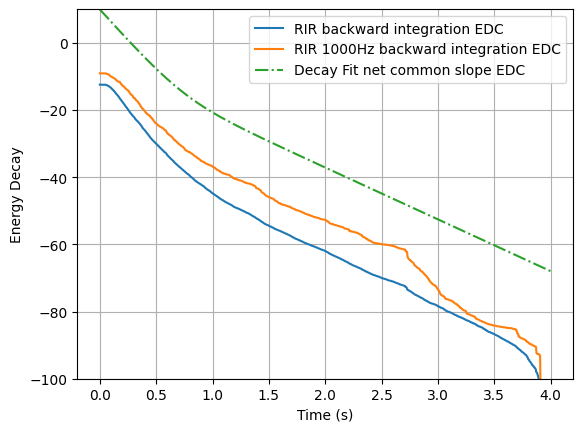

tensor(605.5591, dtype=torch.float64)


In [21]:
import torch 

ref_int = schroeder_backward_int(ref_rir.squeeze(), normalize=False)
ref_filt_int = schroeder_backward_int(ref_rir_filt.squeeze(), normalize=False)
plt.plot(time_axis[:-1], 10*np.log10(ref_int), label='RIR backward integration EDC')
plt.plot(time_axis, 10*np.log10(ref_filt_int), '-', label='RIR 1000Hz backward integration EDC')
plt.plot(time_axis, 10*np.log10(edc_decayfitnet), '-.', label='Decay Fit net common slope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.ylim(-100, 10)
plt.legend()
plt.grid(True)
plt.show()

loss_fn = torch.nn.MSELoss()
this_mse = loss_fn(10 * torch.log10(torch.tensor(np.expand_dims(ref_int[:-int(0.05*L)+1], (0, -1)).copy())), 
                   10 * torch.log10(torch.tensor(np.expand_dims(edc_decayfitnet[:-int(0.05*L)], (0, -1)).copy())))
print(this_mse)
